In [ ]:
!unzip "/content/Dataset (3).zip"

Archive:  /content/Dataset (3).zip
replace images.cv_jzk6llhf18tm3k0kyttxz/readme.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_path='/content/images.cv_jzk6llhf18tm3k0kyttxz/data/train'
val_path = "/content/images.cv_jzk6llhf18tm3k0kyttxz/data/test"
train_dataset=keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224,224),
    batch_size=32
)
val_dataset=keras.utils.image_dataset_from_directory(
    val_path,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 6225 files belonging to 11 classes.
Using 4980 files for training.
Found 3187 files belonging to 11 classes.
Using 637 files for validation.


In [ ]:
num_classes = len(train_dataset.class_names)
num_classes

11

In [ ]:
model = Sequential()

# Block 1
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 4
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    88,605,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,985,483 (339.45 MB)

 Trainable params: 88,983,563 (339.45 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
x_train, y_train = train_dataset.as_numpy_iterator().next()
x_val, y_val = val_dataset.as_numpy_iterator().next()

In [ ]:
x_train.shape

(32, 224, 224, 3)

In [ ]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step - accuracy: 0.0625 - loss: 3.7132 - val_accuracy: 0.0312 - val_loss: 48.4259
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.9375 - loss: 0.2560 - val_accuracy: 0.0312 - val_loss: 56.5462
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - accuracy: 1.0000 - loss: 0.0519 - val_accuracy: 0.0312 - val_loss: 58.0076
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 1.0000 - loss: 0.0341 - val_accuracy: 0.0312 - val_loss: 56.1623
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 0.0312 - val_loss: 52.7781
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 1.0000 - loss: 0.0171 - val_accuracy: 0.0312 - val_loss: 48.6825
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 0.0312 - val_loss: 44.6516
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - accuracy: 1.0000 - loss: 0.0263 - val_accuracy: 0.0000e+00 - val_lo

In [ ]:
# EVALUATION FOR TRAIN AND TEST DATA
model.evaluate(x_train,y_train)
model.evaluate(x_val,y_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1250 - loss: 24.0797
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0312 - loss: 33.7109


[33.71094512939453, 0.03125]

# Transfer Learing

In [ ]:
from tensorflow.keras.applications import VGG16,MobileNetV2,ResNet50,InceptionV3,Xception,DenseNet121

In [ ]:
train_dir = "/content/images.cv_jzk6llhf18tm3k0kyttxz/data/train"
test_dir = "/content/images.cv_jzk6llhf18tm3k0kyttxz/data/test"

# Data Augumentation
train_datagen=ImageDataGenerator(rescale=1./255
                                 ,shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True,
                                 rotation_range=30,
                                 fill_mode='nearest',
                                 validation_split=0.2)

test_datagen=ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(224,224),
                                                    batch_size=32,
                                                    class_mode='categorical')

test_generator = test_datagen.flow_from_directory(test_dir,
                                                  target_size=(224,224),
                                                  batch_size=32,
                                                  class_mode='categorical')

# Loading PreTrained model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
num_classes = len(train_generator.class_indices)

for layers in base_model.layers:
  layers.trainable = False

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Found 6225 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    32,113,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,376,779 (131.14 MB)

 Trainable params: 32,118,795 (122.52 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.fit(train_generator, epochs=10, validation_data=test_generator, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.7037 - loss: 1.4017 - val_accuracy: 0.9812 - val_loss: 0.0651
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 551s 3s/step - accuracy: 0.9356 - loss: 0.2071 - val_accuracy: 0.9853 - val_loss: 0.0367
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 550s 3s/step - accuracy: 0.9541 - loss: 0.1319 - val_accuracy: 0.9915 - val_loss: 0.0300
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 570s 3s/step - accuracy: 0.9638 - loss: 0.1001 - val_accuracy: 0.9906 - val_loss: 0.0275
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 576s 3s/step - accuracy: 0.9674 - loss: 0.1004 - val_accuracy: 0.9918 - val_loss: 0.0300
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - accuracy: 0.9715 - loss: 0.0807 - val_accuracy: 0.9865 - val_loss: 0.0454
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 557s 3s/step - accuracy: 0.9699 - loss: 0.1069 - val_accuracy: 0.9944 - val_loss: 0.0159
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 563s 3s/step - accuracy: 0.9771 - loss: 0.0575 - val_accu

In [ ]:
# Evaluation for train and test data
model.evaluate(train_generator)
model.evaluate(test_generator)

  1/195 ━━━━━━━━━━━━━━━━━━━━ 8:08 3s/step - accuracy: 1.0000 - loss: 0.0028

KeyboardInterrupt: 

In [ ]:
result = model.predict("/content/sanpperfish.jpg")
result

ValueError: Unrecognized data type: x=/content/sanpperfish.jpg (of type <class 'str'>)

In [ ]:
model.save("multiclassFish_mobilenetv2.keras")

In [ ]:
model.predict("/content/sanpperfish.jpg")

ValueError: Unrecognized data type: x=/content/sanpperfish.jpg (of type <class 'str'>)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted class: fish sea_food shrimp
Probability: 0.99


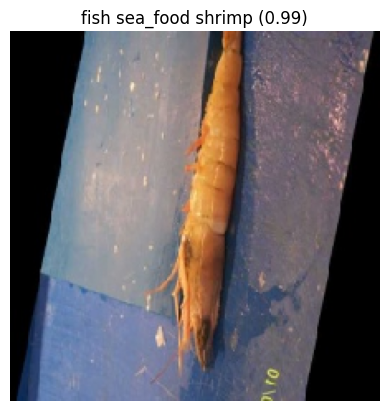

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
img_path = "/content/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food shrimp/00N6DBDOZ8R3.jpg"  # your image path
img = image.load_img(img_path, target_size=(224, 224))  # resize
img_array = image.img_to_array(img)  # convert to array
img_array = img_array / 255.0        # rescale like training
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

predictions = model.predict(img_array)          # model output
predicted_index = np.argmax(predictions, axis=1)  # index of highest probability

# Use class labels from your train_generator
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[predicted_index[0]]
predicted_prob = predictions[0][predicted_index[0]]

print(f"Predicted class: {predicted_class}")
print(f"Probability: {predicted_prob:.2f}")

plt.imshow(img)
plt.title(f"{predicted_class} ({predicted_prob:.2f})")
plt.axis('off')
plt.show()
